In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from utils import *
from config import *
from data_provider.data_factory import data_provider

# _, train_loader = data_provider(args, flag='train')
# _, val_loader = data_provider(args, flag='val')

In [5]:
# 노트북 1번 셀
import torch
from argparse import Namespace
import matplotlib.pyplot as plt

from data_provider.data_factory import data_provider

In [6]:

def dct_matrix(T: int, device=None, dtype=torch.float32):
    device = device or 'cpu'
    n = torch.arange(T, device=device, dtype=dtype).reshape(1, T)
    k = torch.arange(T, device=device, dtype=dtype).reshape(T, 1)
    C = torch.cos(math.pi * (n + 0.5) * k / T) * math.sqrt(2.0 / T)
    C[0, :] *= 1 / math.sqrt(2.0)
    return C  # (T,T)

def dct_time(x: torch.Tensor, C: torch.Tensor, time_dim: int = 1):
    # (B,T,D) 가정 버전
    if time_dim != 1:
        perm = list(range(x.dim()))
        perm[1], perm[time_dim] = perm[time_dim], perm[1]
        x = x.permute(*perm).contiguous()
        need_inv = (perm != list(range(len(perm))))
    else:
        need_inv = False

    Y = torch.matmul(x.transpose(1, 2).contiguous(), C.t()).transpose(1, 2)

    if need_inv:
        inv = list(range(len(perm)))
        inv[1], inv[time_dim] = inv[time_dim], inv[1]
        Y = Y.permute(*inv).contiguous()
    return Y

def idct_time(xc: torch.Tensor, C: torch.Tensor, time_dim: int = 1):
    if time_dim != 1:
        perm = list(range(xc.dim()))
        perm[1], perm[time_dim] = perm[time_dim], perm[1]
        xc = xc.permute(*perm).contiguous()
        need_inv = (perm != list(range(len(perm))))
    else:
        need_inv = False

    Y = torch.matmul(xc.transpose(1, 2).contiguous(), C).transpose(1, 2)

    if need_inv:
        inv = list(range(len(perm)))
        inv[1], inv[time_dim] = inv[time_dim], inv[1]
        Y = Y.permute(*inv).contiguous()
    return Y

def lowpass_memory(x_bin: torch.Tensor,
                         keep_ratio: float = 0.25,
                         time_dim: int = 1,
                         center: bool = True,
                         rebinarize: bool = False,
                         thresh: float = 0.5):
    """
    x_bin: (B,T,D) 바이너리 스파이크(0/1) 또는 {0,1}로 해석 가능한 텐서
    return: x_lp (연속 또는 재이산화), coeff_lp (저주파만 남긴 DCT 계수)
    """
    x = x_bin.to(dtype=torch.float32)
    T = x.shape[time_dim]
    C = dct_matrix(T, device=x.device, dtype=x.dtype)

    # (선택) 평균 제거: DC가 너무 크면 저역만 남길 때 정보가 평준화됨
    if center:
        mean = x.mean(dim=time_dim, keepdim=True)
        x = x - mean

    # DCT
    Xc = dct_time(x, C, time_dim=time_dim)

    # 저주파 유지
    k = max(1, int(math.ceil(T * keep_ratio)))
    mask = torch.zeros(T, device=x.device, dtype=x.dtype)
    mask[:k] = 1
    shp = [1] * x.dim()
    shp[time_dim] = T
    mask = mask.view(*shp)
    Xc_lp = Xc * mask

    # 역변환
    x_lp = idct_time(Xc_lp, C, time_dim=time_dim)

    # (선택) 평균 복원: 장기 추세를 살리고 싶다면
    if center:
        x_lp = x_lp + mean

    # (선택) 재이산화: 추론용/스파이크 유지가 필요할 때만
    if rebinarize:
        # 주의: 역전파 필요하면 STE 등으로 처리
        x_lp = (x_lp > thresh).to(x.dtype)

    return x_lp, Xc_lp, mask


In [20]:
# 노트북 2번 셀
DATA = 'ETTm2'

# bash 스크립트와 parser 설정을 반영한 args
args = Namespace(
    # ----- data 관련 인자 (data_arg 그룹) -----
    data_name=DATA,                        # --data
    data='custom',
    task_name='forecasting',             # --task_name
    freq='m',                            # --freq
    # root_path=f'/home/yschoi/CLS_spiking_transformer/Bio-inspired-Spiking-Memory-Transformer-for-time-series-representation-learning/forecasting/dataset/{DATA}',
    root_path=f'/home/yschoi/CLS_spiking_transformer/Bio-inspired-Spiking-Memory-Transformer-for-time-series-representation-learning/forecasting/dataset/ETT-small',
    data_path=DATA +'.csv',               # --data_path
    embed='timeF',                       # --embed
    features='M',                        # --features
    target='OT',                         # --target (ETT 계열에서 사용하는 타깃 컬럼명)
    c_in=7,                              # --c_in (입력 채널 수)

    # forecasting lengths
    seq_len=96,                         # --seq_len (입력 길이)
    label_len=48,                        # --label_len
    pred_len=96,                         # --pred_len (여기서는 96으로; 바꾸고 싶으면 수정하면 됨)

    seasonal_patterns='Monthly',         # --seasonal_patterns
    sampling='None',                     # --sampling
    train_val_ratio=None,                # --ratio
    n_folds=1,                           # --n_folds
    best_folds=0,                        # --best_folds

    # ----- loader/training에 필요한 기타 인자들 (대부분 data_provider에서 참조) -----
    batch_size=64,                       # -bs 64
    num_workers=4,                       # DataLoader num_workers (필요 없으면 0으로 두어도 됨)

    # 아래 것들은 data_provider가 쓰지는 않아도, 전체 코드 구조상 필요할 수 있어 추가
    gating='original',
    scheduler='reduce',
    no_bias=True,
    s=True,                              # -s (store 모델 등)
    test=True,                           # --test
    devices=1,                           # -nd 1 (gpu 개수 관련 인자를 이렇게 두는 경우 많음)
    e=50,                                # -e 50 (epoch 수, 여기서는 의미 X)
    warm_up_epoch=0,
    emb=128,
    mlp_ratios=4,
    nh=8,
    lr=0.0001,
    alpha=0.1,
    time_layers=2,
    patience=2
)

print(args)


Namespace(data_name='ETTm2', data='custom', task_name='forecasting', freq='m', root_path='/home/yschoi/CLS_spiking_transformer/Bio-inspired-Spiking-Memory-Transformer-for-time-series-representation-learning/forecasting/dataset/ETT-small', data_path='ETTm2.csv', embed='timeF', features='M', target='OT', c_in=7, seq_len=96, label_len=48, pred_len=96, seasonal_patterns='Monthly', sampling='None', train_val_ratio=None, n_folds=1, best_folds=0, batch_size=64, num_workers=4, gating='original', scheduler='reduce', no_bias=True, s=True, test=True, devices=1, e=50, warm_up_epoch=0, emb=128, mlp_ratios=4, nh=8, lr=0.0001, alpha=0.1, time_layers=2, patience=2)


In [21]:
# 노트북 3번 셀

# device 선택 (선택 사항)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

train_dataset, train_loader = data_provider(args, flag='train')
print("Train dataset length:", len(train_dataset))

# 한 배치만 꺼내서 shape 확인
first_batch = next(iter(train_loader))

# 보통 forecasting용 data_provider는
# (batch_x, batch_y, batch_x_mark, batch_y_mark) 를 반환하는 패턴이 많음
if isinstance(first_batch, (list, tuple)) and len(first_batch) >= 2:
    batch_x = first_batch[0]
    batch_y = first_batch[1]
else:
    # 혹시 다른 형식이면 일단 첫 번째 항목을 입력으로 가정
    batch_x = first_batch

print("batch_x shape:", batch_x.shape)


Using device: cuda
train 48585
Train dataset length: 48585
batch_x shape: torch.Size([64, 96, 7])


In [22]:
color = ["#66C5CC","#F6CF71","#F89C74","#DCB0F2","#87C55F","#9EB9F3","#FE88B1","#C9DB74","#8BE0A4","#B497E7","#D3B484","#B3B3B3"]


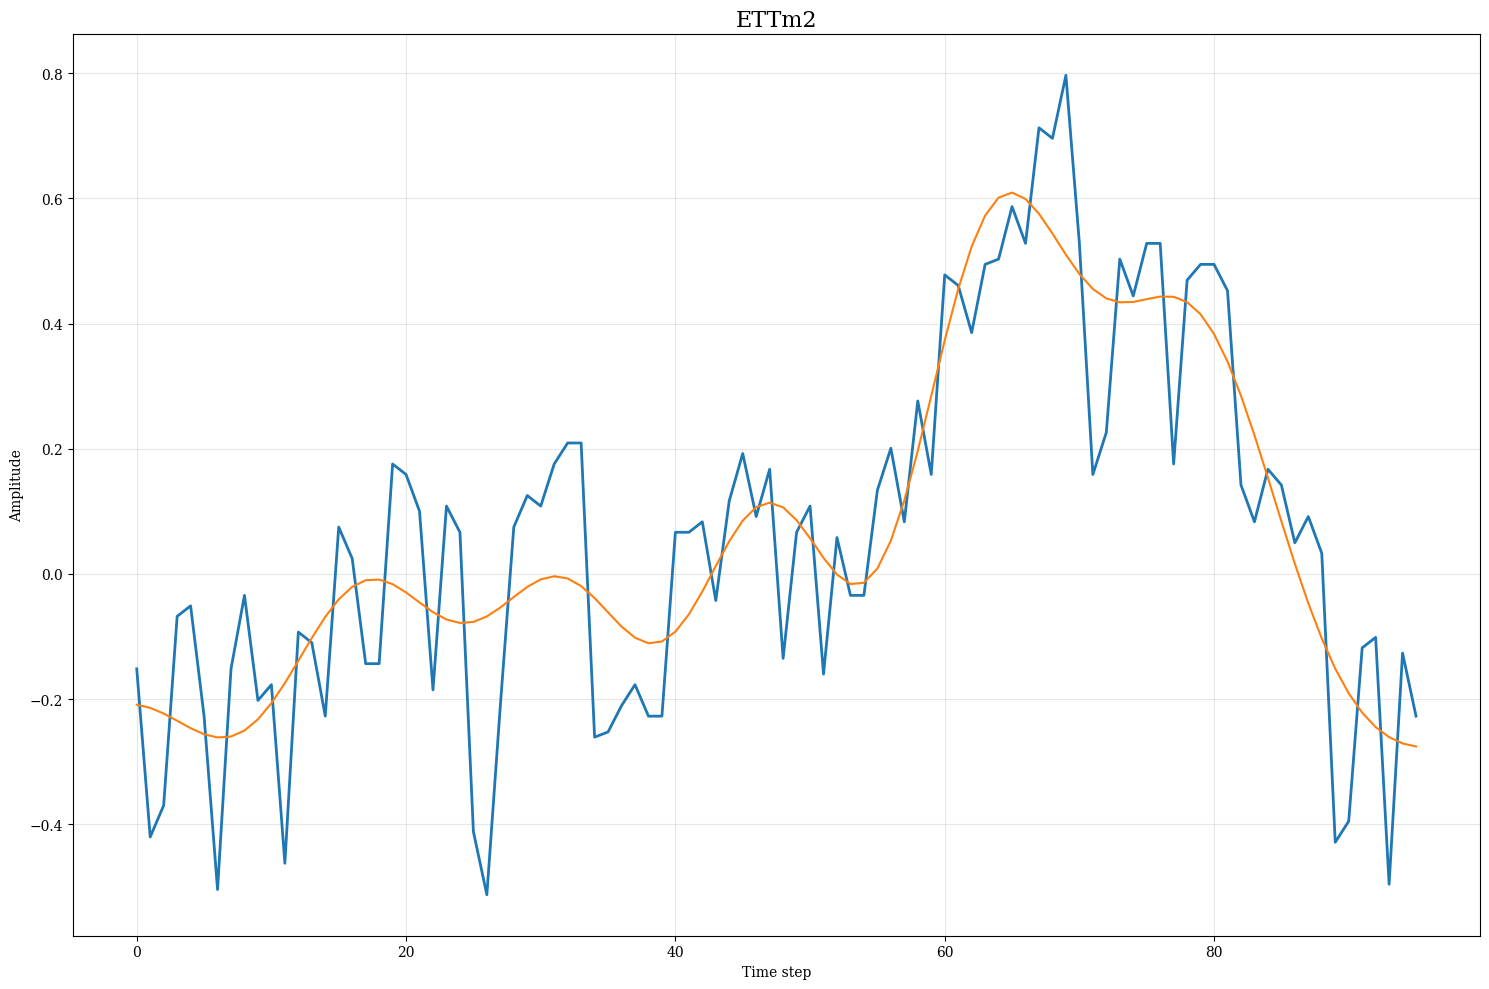

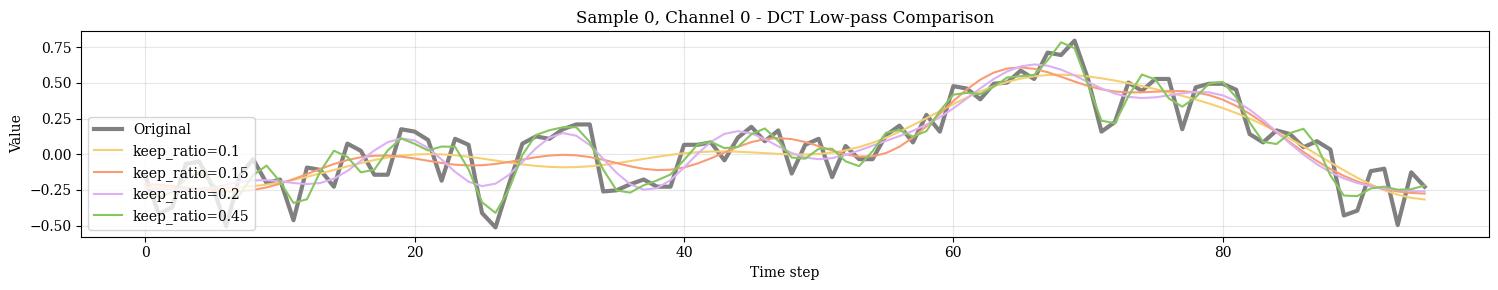

In [24]:
# 노트북 4번 셀
import math
# batch_x: [B, seq_len, c_in] 라고 가정
# 첫 번째 배치, 첫 번째 샘플만 사용
# --------------------------
# 1) 시각화할 샘플/채널 선택
# --------------------------
sample_idx = 0      # batch 안에서 몇 번째 샘플을 볼지
channel_idx = 0     # 몇 번째 채널을 볼지 (c_in=7이면 0~6)
plt.rcParams['font.family'] = 'Serif'
# batch_x: [B, T, D] 라고 가정 (B=batch_size, T=seq_len, D=c_in)
x_sample = batch_x[sample_idx:sample_idx+1].to(torch.float32)  # [1, T, D]

# --------------------------
# 2) low-pass filtering
# --------------------------
keep_ratio = 0.15 # T 중 앞 k = ceil(T*keep_ratio) 개의 저주파만 남김

x_lp, Xc_lp, mask = lowpass_memory(
    x_sample, 
    keep_ratio=keep_ratio, 
    time_dim=1, 
    center=True, 
    rebinarize=False
)  # x_lp: [1, T, D]

# --------------------------
# 3) CPU로 가져와서 numpy로 변환
# --------------------------

orig_ts = x_sample[0, :, channel_idx].detach().cpu().numpy()
lp_ts   = x_lp[0, :, channel_idx].detach().cpu().numpy()

# --------------------------
# 4) 플롯
# --------------------------
plt.figure(figsize=(15, 10))
plt.plot(orig_ts, label='Original signal', linewidth=2.0)
plt.plot(lp_ts,   label=f'Low-pass filtered signal', linewidth=1.5)

# plt.title(f"{args.data_name}, Sample {sample_idx}, Channel {channel_idx}, DCT low-pass filtered signal with keep ratio {keep_ratio}")
plt.title(DATA, fontsize=16)
plt.xlabel("Time step")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.3)
# plt.legend()
plt.tight_layout()
plt.show()

keep_ratios = [0.1, 0.15, 0.2, 0.45]

x_sample = batch_x[sample_idx:sample_idx+1].to(torch.float32)  # [1, T, D]
orig_ts = x_sample[0, :, channel_idx].detach().cpu().numpy()

plt.figure(figsize=(15, 3))
plt.plot(orig_ts, label='Original', linewidth=3.0, color='grey')

for i, kr in enumerate(keep_ratios):
    x_lp, _, _ = lowpass_memory(
        x_sample,
        keep_ratio=kr,
        time_dim=1,
        center=True,
        rebinarize=False
    )
    lp_ts = x_lp[0, :, channel_idx].detach().cpu().numpy()
    plt.plot(lp_ts, label=f'keep_ratio={kr}', linewidth=1.5, color=color[i+1])

plt.title(f"Sample {sample_idx}, Channel {channel_idx} - DCT Low-pass Comparison")
plt.xlabel("Time step")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [14]:
# plt.rcParams['font.family'] = 'Serif'
# plt.rcParams['font.size'] = '12'


In [114]:
root_path='/home/yschoi/CLS_spiking_transformer/Bio-inspired-Spiking-Memory-Transformer-for-time-series-representation-learning/forecasting/dataset/'

In [115]:
def plot_data(data='ETTh2', target='OT'):
    # 노트북 2번 셀
    data_path = data+'.csv'
    # bash 스크립트와 parser 설정을 반영한 args
    csv_path = os.path.join(root_path, data_path)
    df = pd.read_csv(csv_path)

    # ETT 계열 기본 포맷: 'date' 컬럼 + 여러 feature + 'OT'
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')
    # df = df.set_index('date')

    # target 시계열 선택
    ts = df[target].astype(float)
    ts = ts.iloc[1000:2000]
    fig, axes = plt.subplots(1, 1, figsize=(12, 2))
    axes.plot(ts)
    axes.set_title("Original")
    axes.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [116]:
import os
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL

# -----------------------------------------
# 1. 데이터 로드 (ETTh2, target='OT')
# -----------------------------------------
def plot_decom(data='ETTh2', target='OT'):
    # 노트북 2번 셀
    data_path = data+'.csv'
    # bash 스크립트와 parser 설정을 반영한 args
    csv_path = os.path.join(root_path, data_path)
    df = pd.read_csv(csv_path)

    # ETT 계열 기본 포맷: 'date' 컬럼 + 여러 feature + 'OT'
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date')
    df = df.set_index('date')

    # target 시계열 선택
    ts = df[target].astype(float)

    # (선택) 너무 길면 앞부분 일부만 보고 싶을 때
    ts = ts.iloc[1000:2000]

    # -----------------------------------------
    # 2. STL로 "추세+순환" + "계절성" + "잔차" 1차 분해
    #    - period=24: ETTh2는 hourly이므로 24시간(일주기)을 계절성으로 가정
    # -----------------------------------------
    stl = STL(ts, period=24, robust=True)
    stl_res = stl.fit()

    trend_stl = stl_res.trend      # 장기+순환이 섞인 추세 성분
    seasonal = stl_res.seasonal    # 계절성 (24h 주기)
    resid    = stl_res.resid       # 잔차 (불규칙 + 미해명 구조)

    # -----------------------------------------
    # 3. HP filter로 trend_stl을 다시 "추세(아주 장기)" + "순환성"으로 분해
    #    - y_t = trend_long + cycle
    #    - lambda 값(여기선 1600)은 예시용이고, 필요하면 조정 가능
    # -----------------------------------------
    cycle, trend_long = sm.tsa.filters.hpfilter(trend_stl, lamb=1600)

    # 최종 네 성분:
    trend    = trend_long          # 아주 장기적인 추세
    cyclical = cycle               # 경기/레짐 등 순환 성분
    seasonal = seasonal            # 계절성 (24h 주기)
    residual = resid               # 잔차(불규칙 + 작은 이상 등)

    # -----------------------------------------
    # 4. 4행 × 1열 Figure로 시각화
    # -----------------------------------------
    fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(trend)
    axes[0].set_title("Trend")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(seasonal)
    axes[1].set_title("Seasonality")
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(cyclical)
    axes[2].set_title("Cyclical component")
    axes[2].grid(True, alpha=0.3)

    axes[3].plot(residual)
    axes[3].set_title("Residual")
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    
    return {
        "Trend": trend,
        "Seasonal": seasonal,
        "Cyclical": cyclical,
        "Residual": residual,

    }

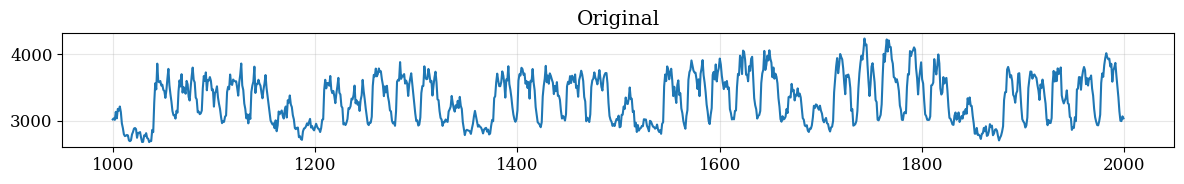

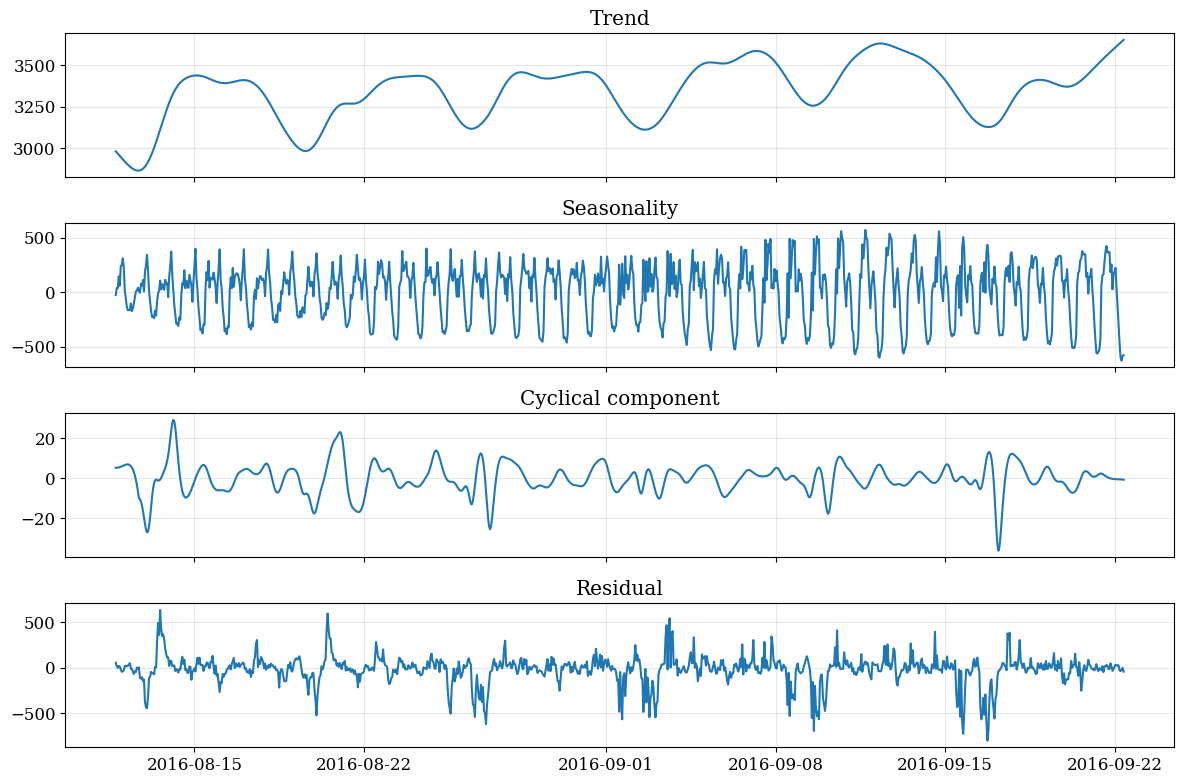

In [183]:
dict_h1 = plot_data('electricity')
dict_h1 = plot_decom('electricity')

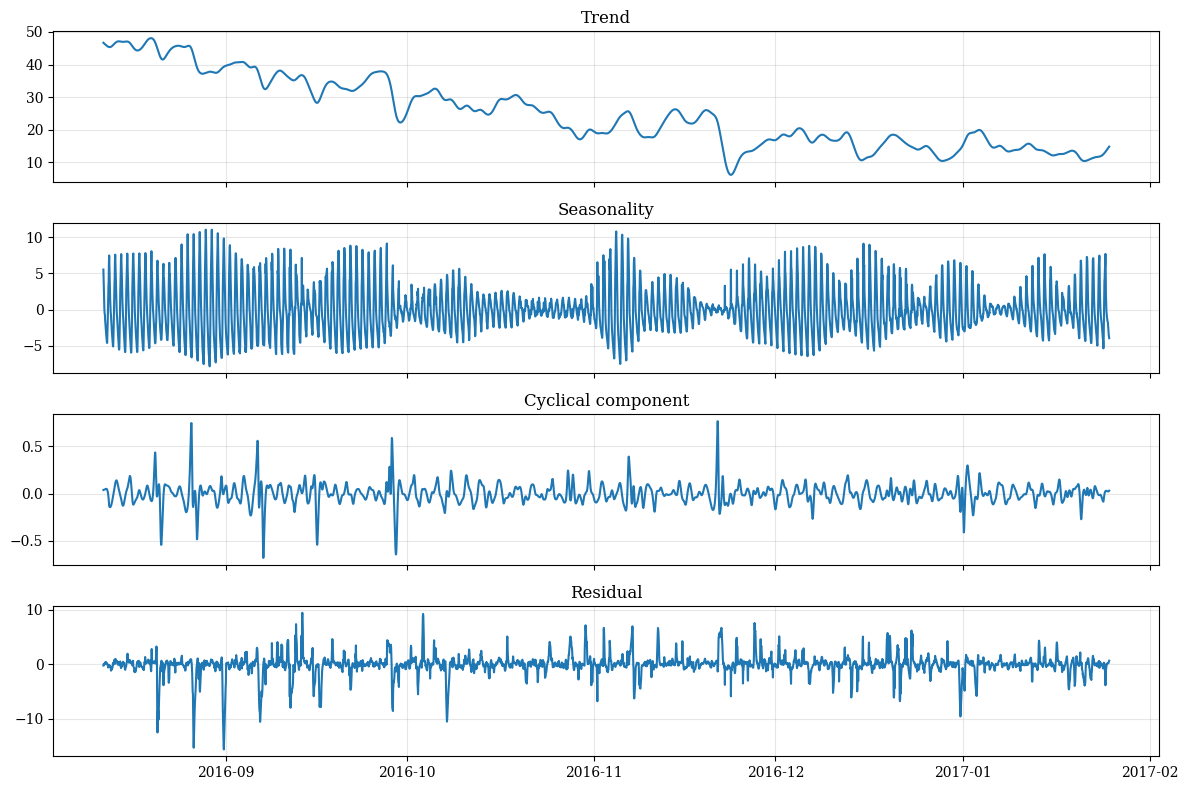

In [45]:
dict_h2 = plot_decom('ETTh2')

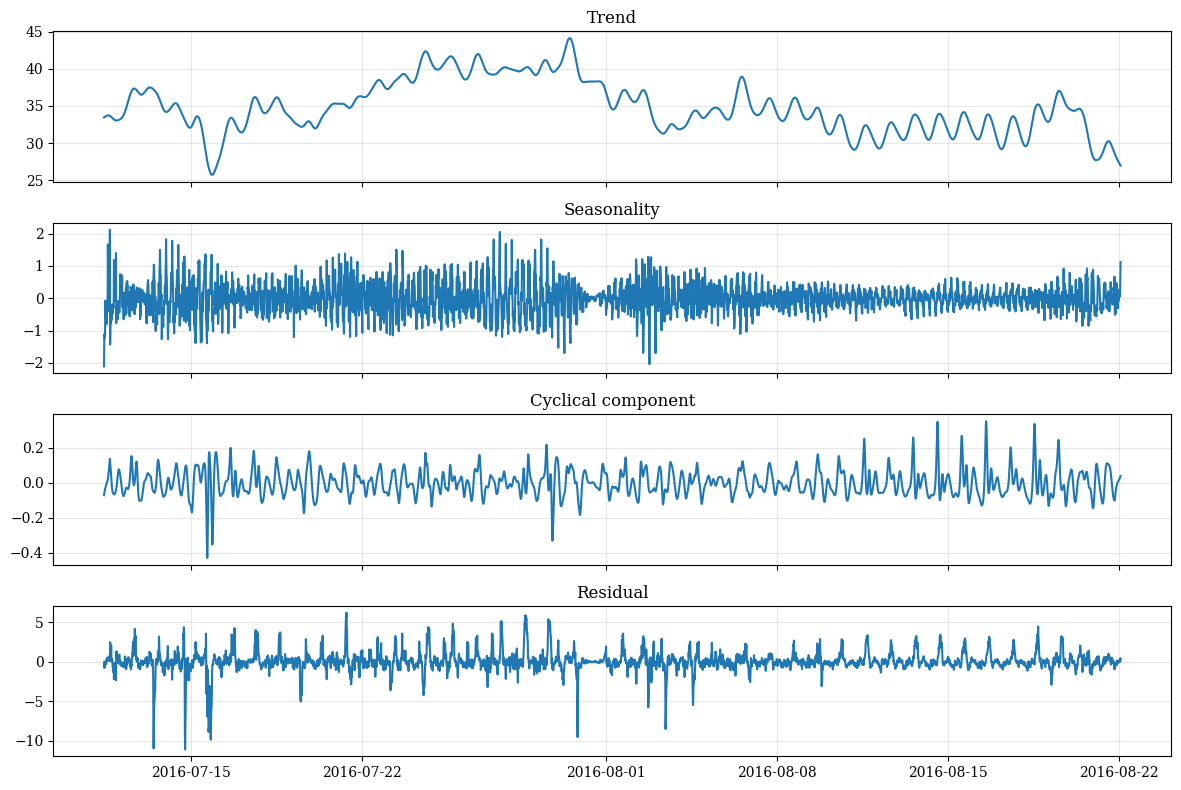

In [46]:
dict_m1 = plot_decom('ETTm1')

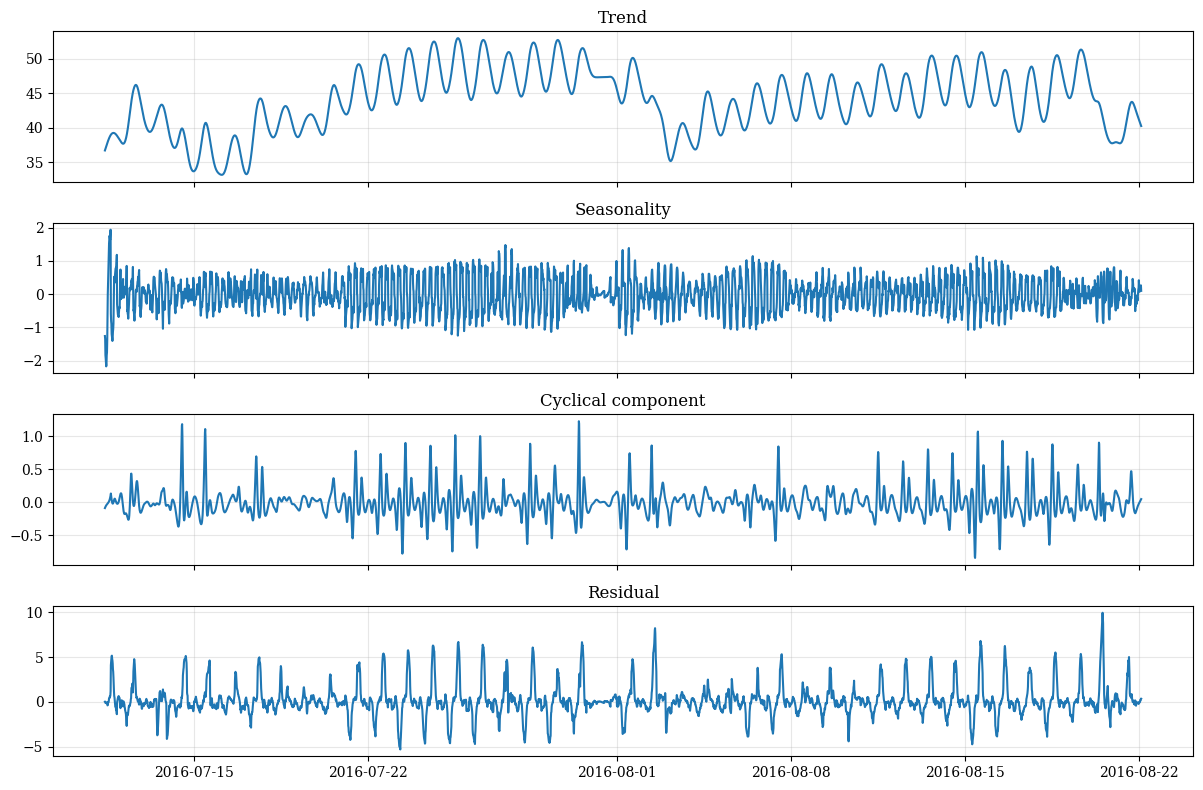

In [47]:
dict_m2 = plot_decom('ETTm2')

In [146]:
def analyze_and_plot_spectra(components, dt=1.0, top_k=15, max_freq=None):
    """
    분해된 시계열 성분(추세, 계절성, 순환성, 잔차)에 대해
    FFT 기반 주파수 스펙트럼을 계산하고, 지배적인 주파수 대역(피크)을 확인하고 시각화한다.

    Args:
        components (dict):
            {"Trend": trend_series,
             "Seasonal": seasonal_series,
             "Cyclical": cyclical_series,
             "Residual": residual_series}
            형태의 dict. 각 value는 1D numpy array 또는 pandas.Series.
        dt (float):
            샘플링 간격 (time step). ETTh2 hourly 기준이면 1.0 (1시간).
            예: 15분 단위면 dt=0.25.
        top_k (int):
            각 성분별로 에너지가 큰 상위 k개 주파수 피크를 출력/표시.
        max_freq (float or None):
            x축에 표시할 최대 주파수 (cycles / time-unit).
            None이면 Nyquist까지 전체 사용.
    """
    n_comp = len(components)
    fig, axes = plt.subplots(n_comp, 1, figsize=(8, 8), sharex=True)
    if n_comp == 1:
        axes = [axes]

    for idx, (name, series) in enumerate(components.items()):
        ax = axes[idx]

        # ------------------------------
        # 1. Series to numpy & 전처리
        # ------------------------------
        if hasattr(series, "values"):
            x = np.asarray(series.values, dtype=float)
        else:
            x = np.asarray(series, dtype=float)

        # NaN 제거 (있는 경우)
        x = x[~np.isnan(x)]
        N = len(x)

        # DC 성분 영향 줄이기 위해 평균 0, 창함수 적용
        x = x - np.mean(x)
        window = np.hanning(N)
        x_win = x * window

        # ------------------------------
        # 2. FFT 및 파워 스펙트럼 계산 (raw)
        # ------------------------------
        freqs = np.fft.rfftfreq(N, d=dt)        # 0 ~ Nyquist
        fft_vals = np.fft.rfft(x_win)
        raw_power = (np.abs(fft_vals) ** 2) / N  # 원본 파워

        # ------------------------------
        # 3. top-k 피크 찾기 (0Hz 제외, raw 기준)
        # ------------------------------
        peak_freqs = []
        if len(raw_power) > 1:
            power_no_dc = raw_power[1:]
            freqs_no_dc = freqs[1:]

            k = min(top_k, len(power_no_dc))
            peak_idx_sorted = np.argsort(power_no_dc)[::-1][:k]
            peak_freqs = freqs_no_dc[peak_idx_sorted]
            peak_powers = power_no_dc[peak_idx_sorted]
            peak_periods = 1.0 / peak_freqs  # freq=0 제외했으므로 안전

            print(f"\n[{name}] 상위 {k} 개 주파수 피크 (raw power 기준)")
            for i, (f, p, T) in enumerate(zip(peak_freqs, peak_powers, peak_periods), start=1):
                print(f"  {i}. freq = {f:.5f} (cycles / time-unit), "
                      f"period ≈ {T:.2f} time-units, power = {p:.4e}")

        # ------------------------------
        # 4. 시각화용 파워 정규화 (DC 제거 + [0,1] 스케일)
        # ------------------------------
        power_for_plot = raw_power.copy()

        if len(power_for_plot) > 0:
            # DC는 시각화에서 0으로 날려서 스케일 깨지는 것 방지
            power_for_plot[0] = 0.0
            max_p = np.max(power_for_plot)
            if max_p > 0:
                power_for_plot = power_for_plot / max_p  # 0~1 스케일

        # Nyquist 이하 특정 구간까지만 보고 싶으면 자르기
        if max_freq is not None:
            mask = freqs <= max_freq
            freqs_plot = freqs[mask]
            power_plot = power_for_plot[mask]
        else:
            freqs_plot = freqs
            power_plot = power_for_plot

        # ------------------------------
        # 5. 스펙트럼 시각화
        # ------------------------------
        ax.plot(freqs_plot, power_plot)
        ax.set_ylabel("Normalized Power")
        ax.set_title(f"{name} - Frequency Spectrum")

        # top-k 피크 위치에 세로선 표시 (플롯 구간 안에 있을 때)
        for f in peak_freqs:
            if (max_freq is None) or (f <= max_freq):
                ax.axvline(f, linestyle="--", alpha=0.3)

        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)

    axes[-1].set_xlabel("Frequency (cycles per time-unit)")  # ETTh2면 time-unit=hour
    plt.tight_layout()
    plt.show()


In [241]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_and_plot_spectra(components, dt=1.0, top_k=15, max_freq=None):
    """
    각 시계열 성분에 대해
    - 위쪽: time domain (original data)
    - 아래쪽: frequency domain (FFT bar spectrum)
    를 하나의 figure 안에 2행으로 시각화.

    Args:
        components (dict):
            {"Trend": trend_series, ...} 형태.
        dt (float): 샘플링 간격.
        top_k (int): 에너지가 큰 상위 k개 주파수 정보를 출력.
        max_freq (float or None): 주파수 x축 상한.
    """

    for name, series in components.items():

        # ------------------------------
        # 1. Series to numpy & 전처리
        # ------------------------------
        if hasattr(series, "values"):
            x = np.asarray(series.values, dtype=float)
        else:
            x = np.asarray(series, dtype=float)

        x = x[~np.isnan(x)]       # NaN 제거
        N = len(x)
        if N == 0:
            print(f"[{name}] 길이가 0이라 건너뜀.")
            continue

        # 시간축
        t = np.arange(N) * dt

        # 평균 제거 + 창 함수
        x_demean = x - np.mean(x)
        window = np.hanning(N)
        x_win = x_demean * window

        # ------------------------------
        # 2. FFT 및 파워 계산
        # ------------------------------
        freqs = np.fft.rfftfreq(N, d=dt)        # 0 ~ Nyquist
        fft_vals = np.fft.rfft(x_win)
        raw_power = (np.abs(fft_vals) ** 2) / N

        # ------------------------------
        # 3. top-k 주파수 위치 (0Hz 제외)
        # ------------------------------
        peak_freqs = np.array([])
        if len(raw_power) > 1:
            power_no_dc = raw_power[1:]
            freqs_no_dc = freqs[1:]

            k = min(top_k, len(power_no_dc))
            peak_idx_sorted = np.argsort(power_no_dc)[::-1][:k]
            peak_freqs = freqs_no_dc[peak_idx_sorted]
            peak_powers = power_no_dc[peak_idx_sorted]
            peak_periods = 1.0 / peak_freqs

            print(f"\n[{name}] 상위 {k} 개 주파수 성분이 나타나는 위치")
            for i, (f, T_, p) in enumerate(zip(peak_freqs, peak_periods, peak_powers), start=1):
                print(f"  {i}. freq = {f:.5f} (cycles / time-unit), "
                      f"period ≈ {T_:.2f} time-units, power = {p:.4e}")

        # ------------------------------
        # 4. 시각화용 파워 정규화 (DC=0, max=1)
        # ------------------------------
        power_for_plot = raw_power.copy()
        if len(power_for_plot) > 0:
            power_for_plot[0] = 0.0          # DC 제거
            max_p = np.max(power_for_plot)
            if max_p > 0:
                power_for_plot = power_for_plot / max_p

        # x축 범위 자르기
        if max_freq is not None:
            mask = freqs <= max_freq
            freqs_plot = freqs[mask]
            power_plot = power_for_plot[mask]
        else:
            freqs_plot = freqs
            power_plot = power_for_plot

        # ------------------------------
        # 5. Figure 생성: 위 time, 아래 bar spectrum
        # ------------------------------
        fig, (ax_time, ax_freq) = plt.subplots(
            2, 1, figsize=(12, 6), sharex=False
        )

        # (a) Time domain
        ax_time.plot(t, x, linewidth=1.0)
        ax_time.set_title(f"{name} - Time Domain Signal (Original Data)")
        ax_time.set_ylabel("Amplitude")
        ax_time.grid(True, alpha=0.3)

        # (b) Frequency domain (bar spectrum)
        if len(freqs_plot) > 1:
            # 막대 폭을 샘플 간격 정도로 설정
            bar_width = freqs_plot[1] - freqs_plot[0]
        else:
            bar_width = 1.0

        ax_freq.bar(freqs_plot, power_plot, width=bar_width, align="center")
        ax_freq.set_title(f"{name} - Frequency Domain (FFT Spectrum)")
        ax_freq.set_xlabel("Frequency (cycles per time-unit)")
        ax_freq.set_ylabel("Normalized Power")
        ax_freq.set_ylim(0, 1.05)
        ax_freq.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()



[Trend] 상위 50 개 주파수 성분이 나타나는 위치
  1. freq = 0.00100 (cycles / time-unit), period ≈ 1000.00 time-units, power = 4.5128e+02
  2. freq = 0.00500 (cycles / time-unit), period ≈ 200.00 time-units, power = 1.3208e+02
  3. freq = 0.00400 (cycles / time-unit), period ≈ 250.00 time-units, power = 7.0160e+01
  4. freq = 0.00800 (cycles / time-unit), period ≈ 125.00 time-units, power = 6.7864e+01
  5. freq = 0.00300 (cycles / time-unit), period ≈ 333.33 time-units, power = 5.5527e+01
  6. freq = 0.00600 (cycles / time-unit), period ≈ 166.67 time-units, power = 3.0091e+01
  7. freq = 0.00900 (cycles / time-unit), period ≈ 111.11 time-units, power = 2.0248e+01
  8. freq = 0.01000 (cycles / time-unit), period ≈ 100.00 time-units, power = 1.3372e+01
  9. freq = 0.00700 (cycles / time-unit), period ≈ 142.86 time-units, power = 8.9516e+00
  10. freq = 0.01100 (cycles / time-unit), period ≈ 90.91 time-units, power = 6.2618e+00
  11. freq = 0.01200 (cycles / time-unit), period ≈ 83.33 time-units, power 

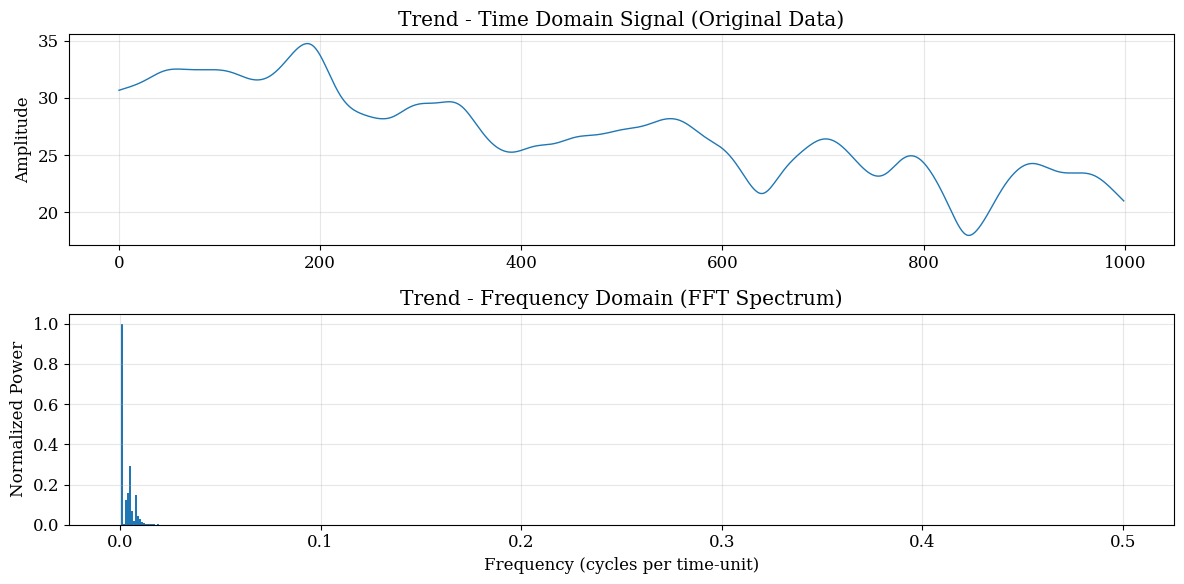


[Seasonal] 상위 50 개 주파수 성분이 나타나는 위치
  1. freq = 0.04200 (cycles / time-unit), period ≈ 23.81 time-units, power = 3.3975e+02
  2. freq = 0.04100 (cycles / time-unit), period ≈ 24.39 time-units, power = 2.0713e+02
  3. freq = 0.04300 (cycles / time-unit), period ≈ 23.26 time-units, power = 4.3861e+01
  4. freq = 0.08400 (cycles / time-unit), period ≈ 11.90 time-units, power = 1.6403e+01
  5. freq = 0.08300 (cycles / time-unit), period ≈ 12.05 time-units, power = 1.5468e+01
  6. freq = 0.12500 (cycles / time-unit), period ≈ 8.00 time-units, power = 8.7841e+00
  7. freq = 0.04000 (cycles / time-unit), period ≈ 25.00 time-units, power = 6.2199e+00
  8. freq = 0.12400 (cycles / time-unit), period ≈ 8.06 time-units, power = 4.0272e+00
  9. freq = 0.12600 (cycles / time-unit), period ≈ 7.94 time-units, power = 2.5702e+00
  10. freq = 0.16700 (cycles / time-unit), period ≈ 5.99 time-units, power = 2.2886e+00
  11. freq = 0.04600 (cycles / time-unit), period ≈ 21.74 time-units, power = 2.1804e+0

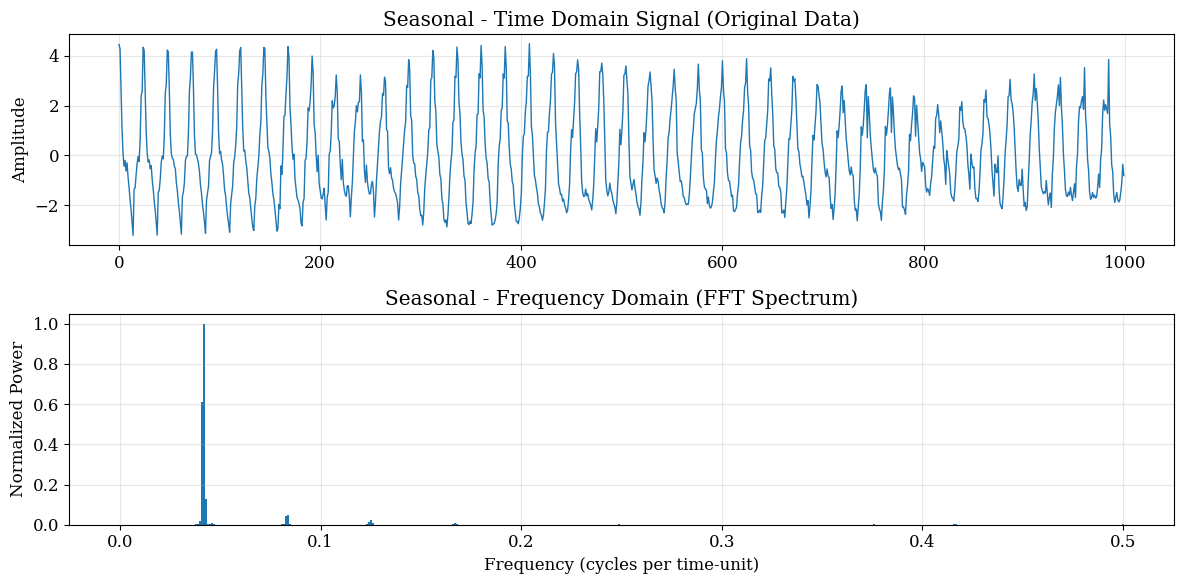


[Cyclical] 상위 50 개 주파수 성분이 나타나는 위치
  1. freq = 0.01900 (cycles / time-unit), period ≈ 52.63 time-units, power = 1.5171e-01
  2. freq = 0.02400 (cycles / time-unit), period ≈ 41.67 time-units, power = 9.6535e-02
  3. freq = 0.02500 (cycles / time-unit), period ≈ 40.00 time-units, power = 8.4646e-02
  4. freq = 0.02200 (cycles / time-unit), period ≈ 45.45 time-units, power = 4.5031e-02
  5. freq = 0.01800 (cycles / time-unit), period ≈ 55.56 time-units, power = 3.9472e-02
  6. freq = 0.03500 (cycles / time-unit), period ≈ 28.57 time-units, power = 3.7417e-02
  7. freq = 0.01500 (cycles / time-unit), period ≈ 66.67 time-units, power = 2.9790e-02
  8. freq = 0.02000 (cycles / time-unit), period ≈ 50.00 time-units, power = 2.9760e-02
  9. freq = 0.01600 (cycles / time-unit), period ≈ 62.50 time-units, power = 2.7778e-02
  10. freq = 0.04100 (cycles / time-unit), period ≈ 24.39 time-units, power = 2.7402e-02
  11. freq = 0.05500 (cycles / time-unit), period ≈ 18.18 time-units, power = 2.558

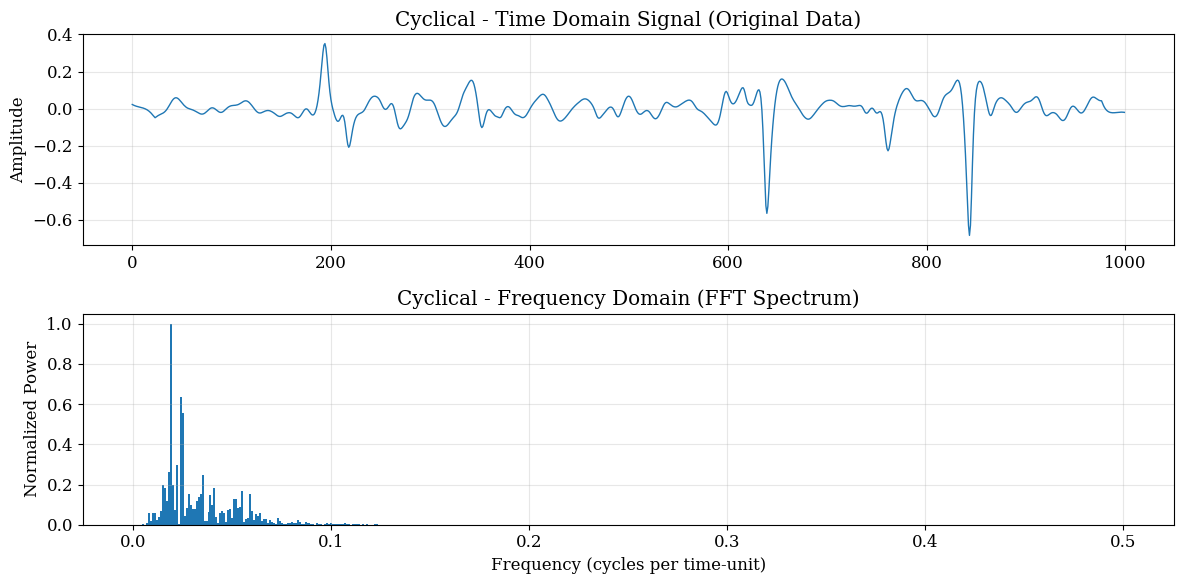


[Residual] 상위 50 개 주파수 성분이 나타나는 위치
  1. freq = 0.01900 (cycles / time-unit), period ≈ 52.63 time-units, power = 1.8932e+01
  2. freq = 0.02600 (cycles / time-unit), period ≈ 38.46 time-units, power = 1.5028e+01
  3. freq = 0.01800 (cycles / time-unit), period ≈ 55.56 time-units, power = 1.4858e+01
  4. freq = 0.02200 (cycles / time-unit), period ≈ 45.45 time-units, power = 1.4844e+01
  5. freq = 0.03400 (cycles / time-unit), period ≈ 29.41 time-units, power = 1.3012e+01
  6. freq = 0.00800 (cycles / time-unit), period ≈ 125.00 time-units, power = 1.2580e+01
  7. freq = 0.04200 (cycles / time-unit), period ≈ 23.81 time-units, power = 1.1639e+01
  8. freq = 0.05000 (cycles / time-unit), period ≈ 20.00 time-units, power = 1.1347e+01
  9. freq = 0.02700 (cycles / time-unit), period ≈ 37.04 time-units, power = 1.1102e+01
  10. freq = 0.01000 (cycles / time-unit), period ≈ 100.00 time-units, power = 1.0363e+01
  11. freq = 0.02500 (cycles / time-unit), period ≈ 40.00 time-units, power = 1.0

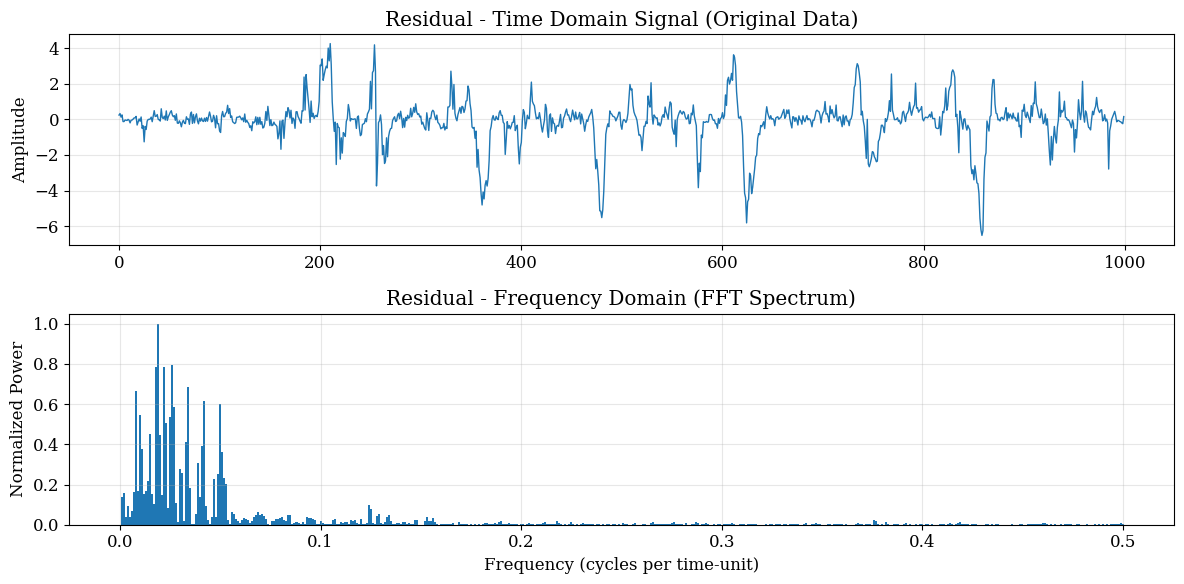

In [242]:
analyze_and_plot_spectra(
    components=dict_h1,
    dt=1.0,
    max_freq=0.5,
    top_k=50,
)


[Trend] 상위 100 개 주파수 성분이 나타나는 위치
  1. freq = 0.00025 (cycles / time-unit), period ≈ 4000.00 time-units, power = 1.9764e+04
  2. freq = 0.00050 (cycles / time-unit), period ≈ 2000.00 time-units, power = 1.5357e+03
  3. freq = 0.00175 (cycles / time-unit), period ≈ 571.43 time-units, power = 1.4139e+03
  4. freq = 0.00150 (cycles / time-unit), period ≈ 666.67 time-units, power = 1.1694e+03
  5. freq = 0.00300 (cycles / time-unit), period ≈ 333.33 time-units, power = 9.9650e+02
  6. freq = 0.00275 (cycles / time-unit), period ≈ 363.64 time-units, power = 8.7053e+02
  7. freq = 0.00600 (cycles / time-unit), period ≈ 166.67 time-units, power = 6.9416e+02
  8. freq = 0.00325 (cycles / time-unit), period ≈ 307.69 time-units, power = 5.8907e+02
  9. freq = 0.00375 (cycles / time-unit), period ≈ 266.67 time-units, power = 5.8512e+02
  10. freq = 0.00200 (cycles / time-unit), period ≈ 500.00 time-units, power = 4.4165e+02
  11. freq = 0.00125 (cycles / time-unit), period ≈ 800.00 time-units, po

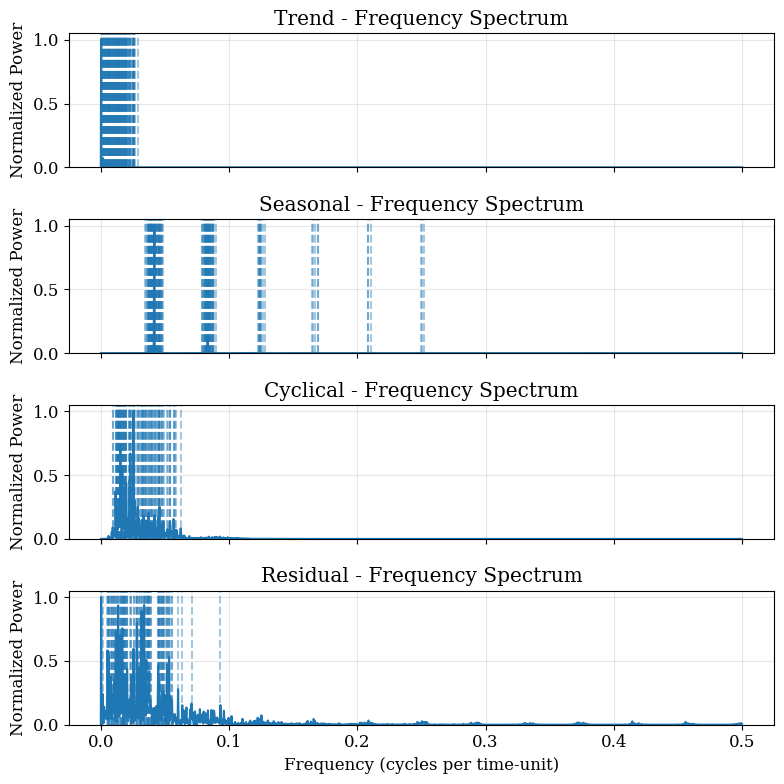

In [159]:
analyze_and_plot_spectra(
    components=dict_h2,
    dt=1.0,
    max_freq=0.5,
    top_k=100,
)


[Trend] 상위 15 개 주파수 피크
  1. freq = 0.00100 (cycles / time-unit), period ≈ 1000.00 time-units, power = 4.4842e+03
  2. freq = 0.00200 (cycles / time-unit), period ≈ 500.00 time-units, power = 2.5891e+03
  3. freq = 0.00300 (cycles / time-unit), period ≈ 333.33 time-units, power = 7.3137e+02
  4. freq = 0.00600 (cycles / time-unit), period ≈ 166.67 time-units, power = 3.9614e+02
  5. freq = 0.00400 (cycles / time-unit), period ≈ 250.00 time-units, power = 3.4188e+02
  6. freq = 0.00500 (cycles / time-unit), period ≈ 200.00 time-units, power = 3.1639e+02
  7. freq = 0.04200 (cycles / time-unit), period ≈ 23.81 time-units, power = 1.9670e+02
  8. freq = 0.04100 (cycles / time-unit), period ≈ 24.39 time-units, power = 1.5578e+02
  9. freq = 0.00700 (cycles / time-unit), period ≈ 142.86 time-units, power = 1.0642e+02
  10. freq = 0.01100 (cycles / time-unit), period ≈ 90.91 time-units, power = 6.6574e+01
  11. freq = 0.03500 (cycles / time-unit), period ≈ 28.57 time-units, power = 6.3223e+0

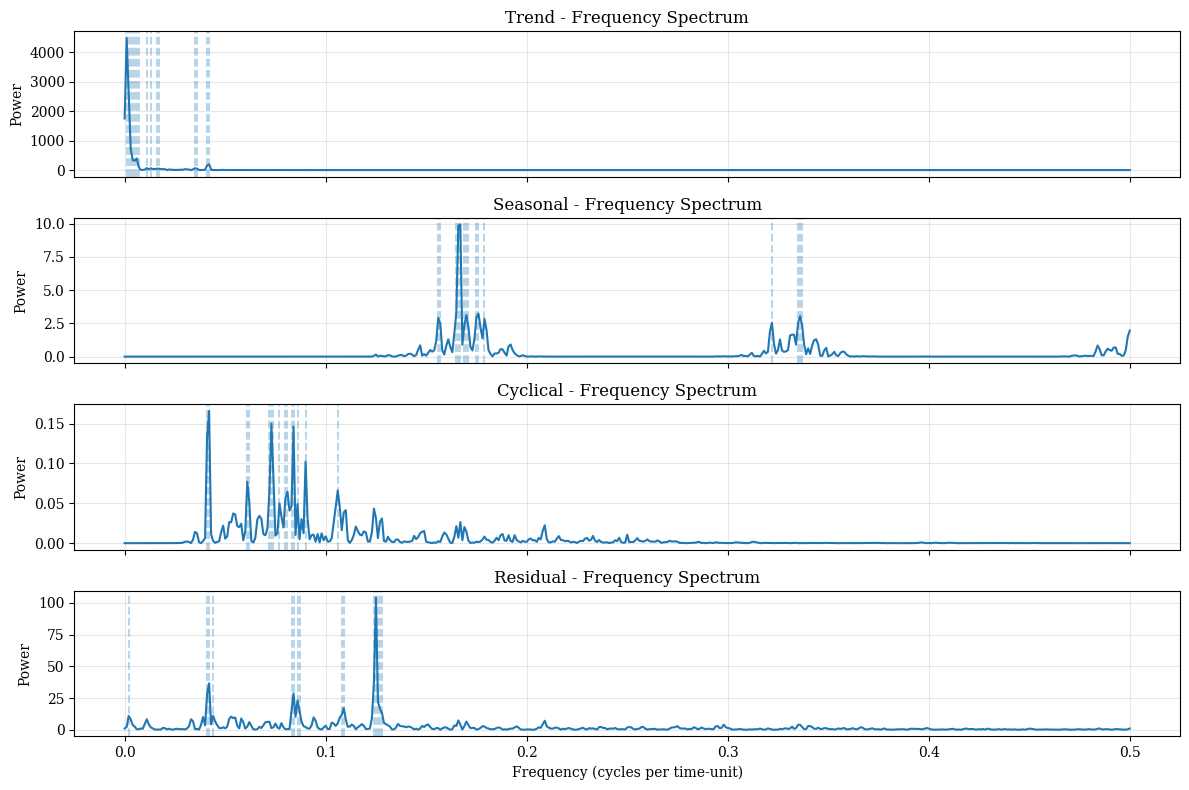

In [95]:
analyze_and_plot_spectra(
    components=dict_m1,
    dt=0.25,
    max_freq=0.5
)


[Trend] 상위 15 개 주파수 피크
  1. freq = 0.00200 (cycles / time-unit), period ≈ 500.00 time-units, power = 3.6234e+03
  2. freq = 0.04200 (cycles / time-unit), period ≈ 23.81 time-units, power = 2.0546e+03
  3. freq = 0.00300 (cycles / time-unit), period ≈ 333.33 time-units, power = 1.4988e+03
  4. freq = 0.00100 (cycles / time-unit), period ≈ 1000.00 time-units, power = 1.4599e+03
  5. freq = 0.04100 (cycles / time-unit), period ≈ 24.39 time-units, power = 1.4288e+03
  6. freq = 0.00500 (cycles / time-unit), period ≈ 200.00 time-units, power = 5.4155e+02
  7. freq = 0.00600 (cycles / time-unit), period ≈ 166.67 time-units, power = 4.3366e+02
  8. freq = 0.00400 (cycles / time-unit), period ≈ 250.00 time-units, power = 3.1344e+02
  9. freq = 0.00700 (cycles / time-unit), period ≈ 142.86 time-units, power = 1.7408e+02
  10. freq = 0.01200 (cycles / time-unit), period ≈ 83.33 time-units, power = 1.3184e+02
  11. freq = 0.04300 (cycles / time-unit), period ≈ 23.26 time-units, power = 1.0068e+0

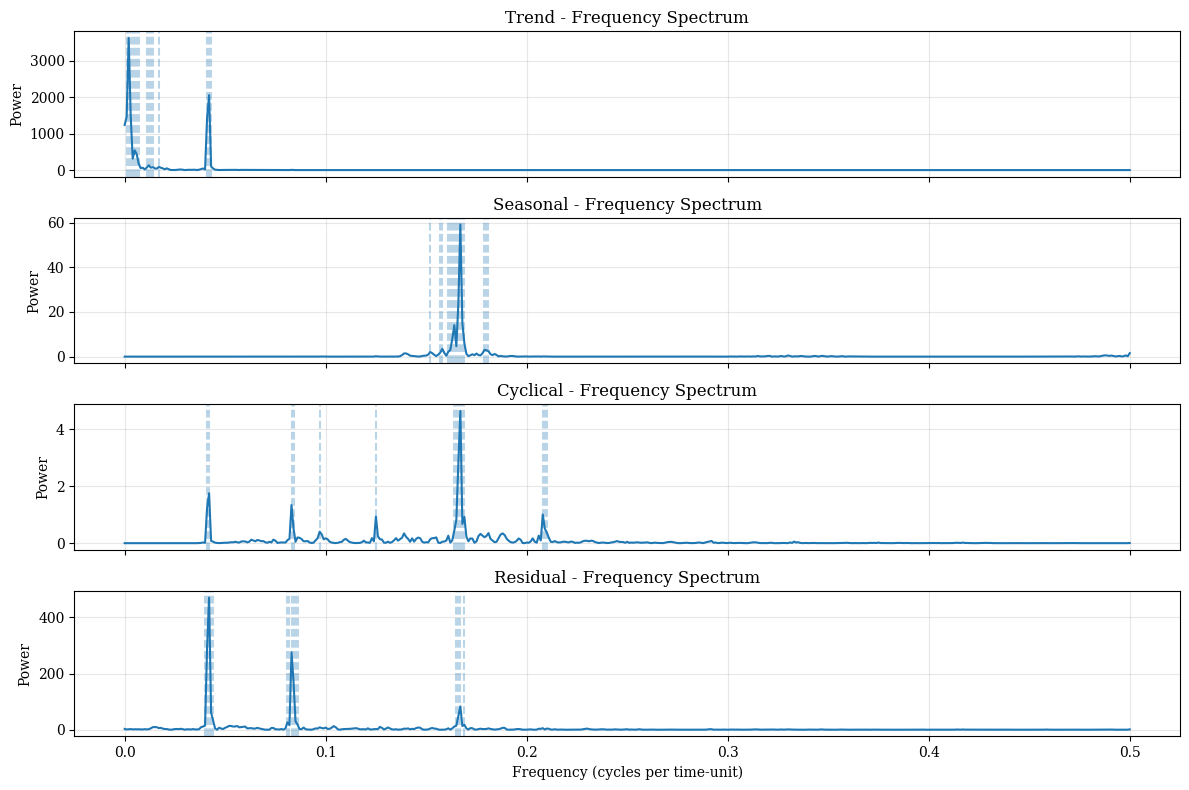

In [98]:
analyze_and_plot_spectra(
    components=dict_m2,
    dt=0.25,
    max_freq=0.5
)

In [88]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_ett_period_bands(
                          data_name=None,
                          target_col=None,
                          dt=None):
    """
    ETT 계열(시간 단위: hour)을 기준으로,
    원 시계열(단일 컬럼)의 에너지가 어떤 '기간' 대역에 많이 분포하는지
    보기 위한 메서드.

    주파수 band를 다음 4개로 나눔 (period 기준, hour 단위):

      - VeryLow : >= 30일      (period >= 30d)
      - Low     : 7일 ~ 30일   (7d <= period < 30d)
      - Mid     : 1일 ~ 7일    (1d <= period < 7d)
      - High    : < 1일        (period < 1d)

    Args:
        args: Namespace (root_path, data_path, data_name/data, target 등을 포함)
        data_name: str or None
        target_col: str or None
        dt: float or None
            - 샘플링 간격 (time step, hour 단위).
              None이면 'ettm' → 0.25, 'etth' → 1.0, 그 외 → 1.0
    """

    # -------------------------------
    # 1. data_name / target_col / dt 설정
    # -------------------------------
    
    if dt is None:
        name_lower = str(data_name).lower()
        if "ettm" in name_lower:
            dt = 0.25   # 15분 = 0.25시간
        elif "etth" in name_lower:
            dt = 1.0    # 1시간
        else:
            dt = 1.0    # 기본값 (hour)

    # -------------------------------
    # 2. CSV 로드 & target 시계열 추출
    # -------------------------------
    csv_path = os.path.join(args.root_path, args.data_path)
    df = pd.read_csv(csv_path)

    # 시간축 정렬 (있으면)
    for time_col in ["date", "timestamp", "time"]:
        if time_col in df.columns:
            df[time_col] = pd.to_datetime(df[time_col])
            df = df.sort_values(time_col)
            df = df.set_index(time_col)
            break

    if target_col not in df.columns:
        raise ValueError(f"target_col '{target_col}' 이(가) 데이터에 없습니다. "
                         f"사용 가능한 컬럼: {df.columns.tolist()}")

    ts = df[target_col].astype(float)

    # -------------------------------
    # 3. FFT & 파워 (DC 제외)
    # -------------------------------
    x = ts.values.astype(float)
    x = x[~np.isnan(x)]
    N = len(x)

    x = x - np.mean(x)
    window = np.hanning(N)
    x_win = x * window

    freqs = np.fft.rfftfreq(N, d=dt)      # 단위: cycles/hour
    fft_vals = np.fft.rfft(x_win)
    power = np.abs(fft_vals) ** 2

    # DC 제거
    freqs_no0 = freqs[1:]
    power_no0 = power[1:]

    # 정규화 후 log 스케일
    max_p = np.max(power_no0)
    power_norm = power_no0 / max_p if max_p > 0 else power_no0
    eps = 1e-12
    power_log = np.log10(power_norm + eps)

    # -------------------------------
    # 4. period 기반 band 정의 (hour 기준)
    # -------------------------------
    # period [hours] 구간 → freq [cycles/hour] 구간
    #   period >= 30d         → freq <= 1/(24*30)
    #   7d <= period < 30d    → 1/(24*30) < freq <= 1/(24*7)
    #   1d <= period < 7d     → 1/(24*7)  < freq <= 1/24
    #   period < 1d           → freq  > 1/24

    h_1d  = 24
    h_7d  = 24 * 7
    h_30d = 24 * 30

    f_30d = 1.0 / h_30d
    f_7d  = 1.0 / h_7d
    f_1d  = 1.0 / h_1d
    f_max = freqs_no0.max()

    bands = {
        ">=30d":  (0.0,   f_30d),        # Very low
        "7~30d":  (f_30d, f_7d),
        "1~7d":   (f_7d,  f_1d),
        "<1d":    (f_1d,  f_max),
    }

    band_powers = {}
    for label, (f_lo, f_hi) in bands.items():
        mask = (freqs_no0 >= f_lo) & (freqs_no0 < f_hi)
        band_powers[label] = power_no0[mask].sum()

    total_power = sum(band_powers.values()) + 1e-12
    band_powers_norm = {k: v / total_power for k, v in band_powers.items()}

    # -------------------------------
    # 5. 시각화: log-spectrum + band bar plot
    # -------------------------------
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))

    # (1) log-spectrum (0 ~ 0.1 cycles/hour 정도까지만 줌인하면 더 잘 보임)
    zoom_mask = freqs_no0 <= 0.1
    axes[0].plot(freqs_no0[zoom_mask], power_log[zoom_mask])
    axes[0].set_title(f"{data_name} - {target_col} log-spectrum (dt={dt} h)")
    axes[0].set_ylabel("log10 Normalized Power")
    axes[0].set_xlabel("Frequency (cycles/hour)")
    axes[0].grid(True, alpha=0.3)

    # (2) band power bar plot
    labels = list(band_powers_norm.keys())
    values = [band_powers_norm[k] for k in labels]
    axes[1].bar(labels, values)
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel("Relative band power")
    axes[1].set_title("Power by period band (hours → days)")
    axes[1].grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 콘솔에 값 출력
    print(f"\n=== {data_name} - {target_col} period-band powers ===")
    for k, v in band_powers_norm.items():
        print(f"{k}: {v*100:.2f}%")


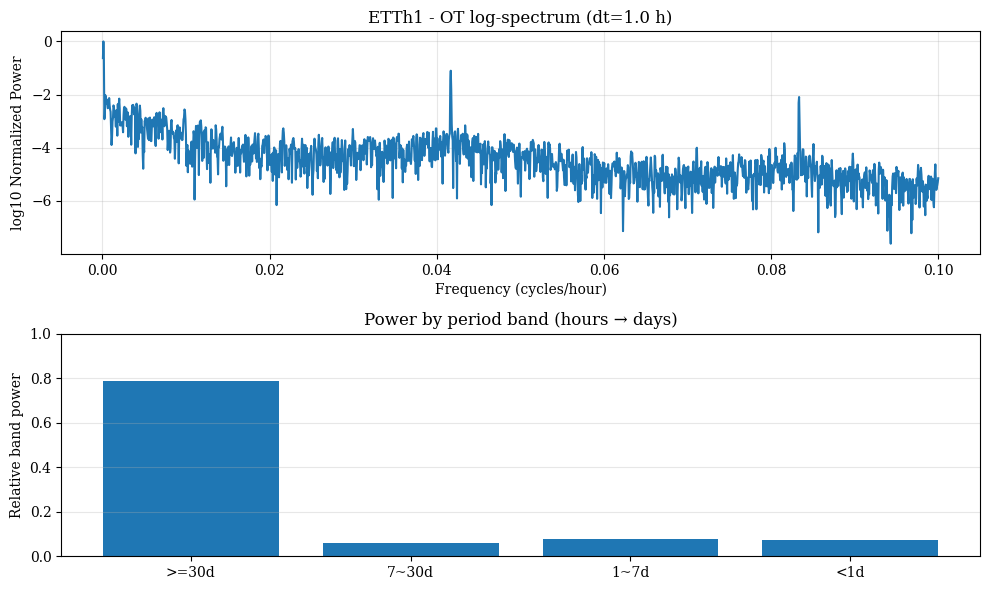


=== ETTh1 - OT period-band powers ===
>=30d: 78.87%
7~30d: 5.93%
1~7d: 7.75%
<1d: 7.45%


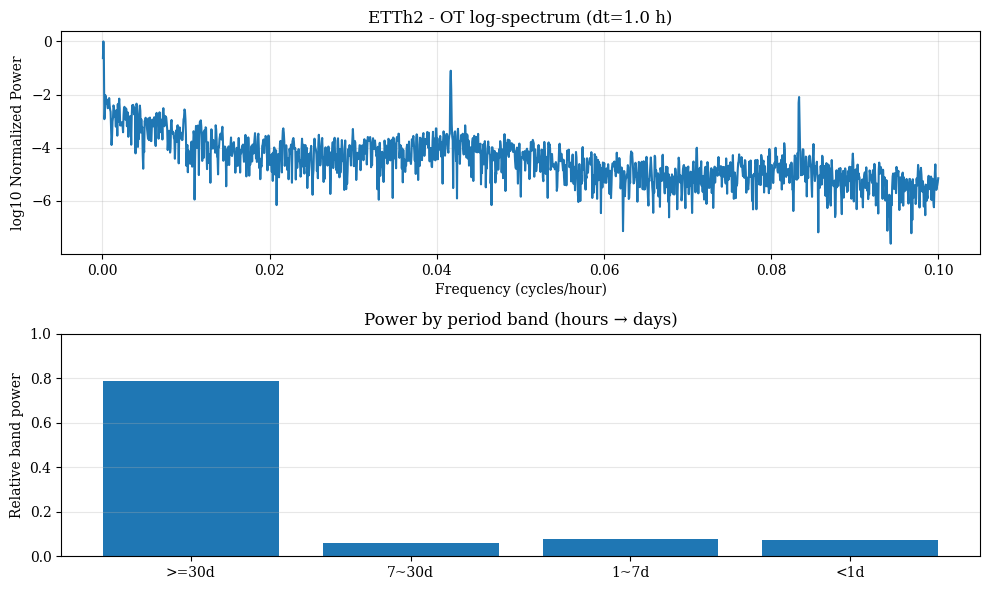


=== ETTh2 - OT period-band powers ===
>=30d: 78.87%
7~30d: 5.93%
1~7d: 7.75%
<1d: 7.45%


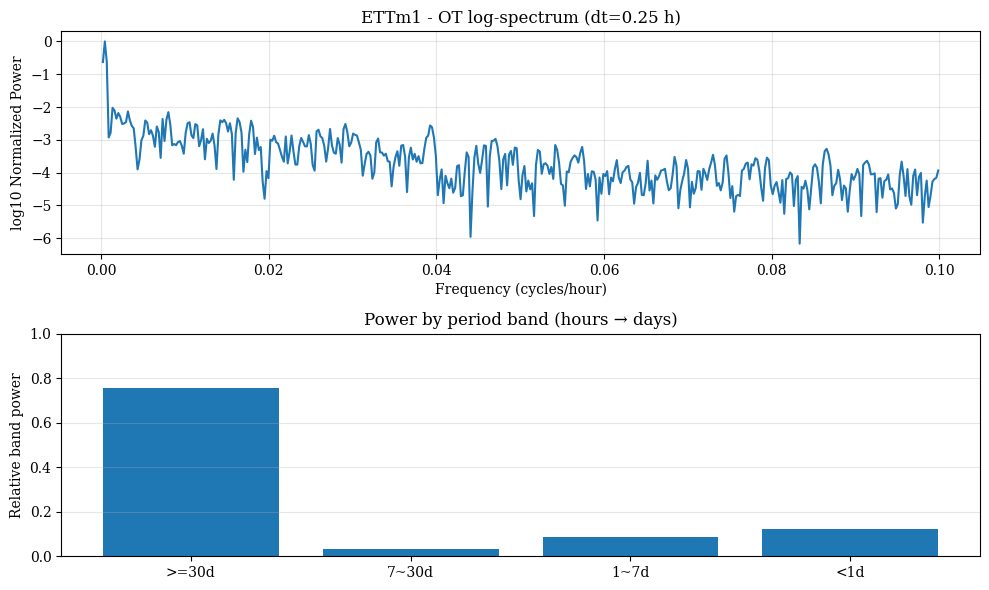


=== ETTm1 - OT period-band powers ===
>=30d: 75.80%
7~30d: 3.15%
1~7d: 8.59%
<1d: 12.46%


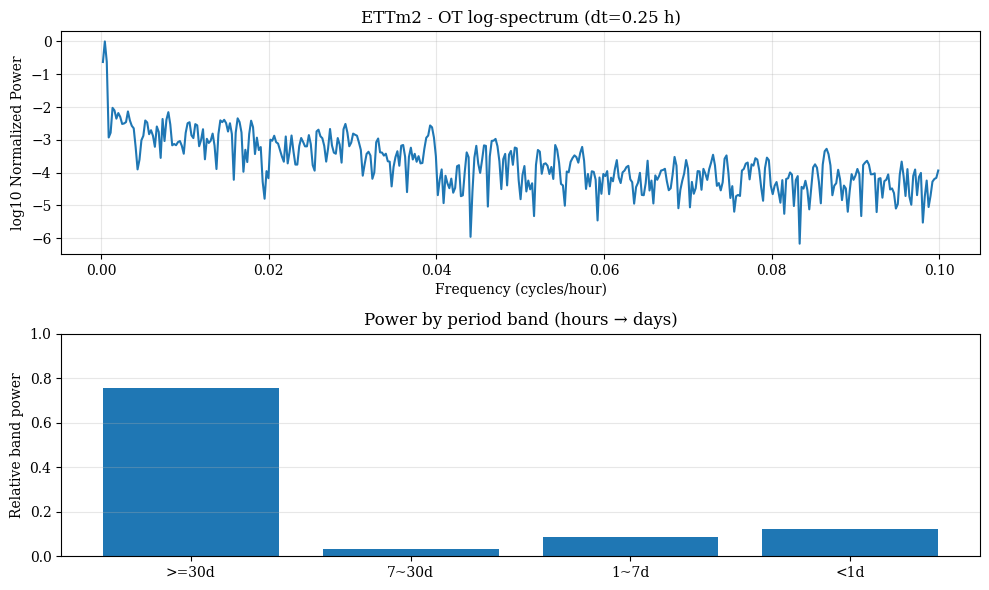


=== ETTm2 - OT period-band powers ===
>=30d: 75.80%
7~30d: 3.15%
1~7d: 8.59%
<1d: 12.46%


In [90]:
# ETTh1
plot_ett_period_bands(data_name="ETTh1", target_col="OT")

# ETTh2
plot_ett_period_bands(data_name="ETTh2", target_col="OT")

# ETTm1 / ETTm2 (dt=0.25로 자동 설정됨)
plot_ett_period_bands(data_name="ETTm1", target_col="OT")
plot_ett_period_bands(data_name="ETTm2", target_col="OT")


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_time_and_fft(root_path,
                      data='ETTh1',
                      target_col='OT',
                      dt=1.0,
                      iloc_start=None,
                      iloc_end=None,
                      max_freq=None,
                      freq_step=None,      # 예: 100 -> 100, 200, 300 Hz ...
                      custom_freqs=None    # 예: [50, 150, 250]
                      ):
    """
    csv(raw data)를 읽어서
    - 윗쪽: original time series
    - 아랫쪽: FFT 스펙트럼(bar, y축 log scale)

    freq_step   : 주파수 간격(Hz). 예) 100 -> 100, 200, 300, ...
    custom_freqs: 직접 지정한 주파수 리스트. 예) [50, 150, 250]
    둘 다 None이면 전체 주파수 영역을 그대로 그림.
    """

    # -----------------------------
    # 1. CSV 로드 & 타깃 시계열 추출
    # -----------------------------
    data_path = data + '.csv'
    csv_path = os.path.join(root_path, data_path)
    df = pd.read_csv(csv_path)

    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').set_index('date')

    ts = df[target_col].astype(float)

    if iloc_start is not None or iloc_end is not None:
        ts = ts.iloc[iloc_start:iloc_end]

    x = ts.values
    N = len(x)
    t = np.arange(N) * dt

    # -----------------------------
    # 2. FFT 계산
    # -----------------------------
    x_demean = x - np.mean(x)
    window = np.hanning(N)
    x_win = x_demean * window

    freqs = np.fft.rfftfreq(N, d=dt)   # Hz
    fft_vals = np.fft.rfft(x_win)
    amp_spectrum = np.abs(fft_vals) / N  # 양수

    # -----------------------------
    # 3. 플롯용 주파수 선택
    # -----------------------------
    # Nyquist까지의 최대 주파수
    nyquist = freqs.max()
    if max_freq is not None:
        nyquist = min(nyquist, max_freq)

    if custom_freqs is not None:
        # 사용자가 직접 지정한 주파수들 중, Nyquist 이하만 사용
        freqs_plot = np.array([f for f in custom_freqs if f <= nyquist])
    elif freq_step is not None:
        # freq_step 간격으로  step, 2*step, ... 형태의 주파수 선택
        freqs_plot = np.arange(freq_step, nyquist + 1e-9, freq_step)
    else:
        # 아무 설정도 없으면 전체 주파수 bin 그리기
        freqs_plot = freqs

    # 각 선택 주파수에 가장 가까운 FFT bin의 amplitude 사용
    if freqs_plot.size == freqs.size and np.allclose(freqs_plot, freqs):
        # 그대로 전체 사용
        amp_plot = amp_spectrum
    else:
        amp_plot = []
        for f0 in freqs_plot:
            idx = np.argmin(np.abs(freqs - f0))
            amp_plot.append(amp_spectrum[idx])
        amp_plot = np.array(amp_plot)

    # log 스케일에서 0 문제 방지용
    eps = 1e-12
    amp_plot = np.clip(amp_plot, eps, None)

    # -----------------------------
    # 4. 플롯
    # -----------------------------
    fig, (ax_time, ax_freq) = plt.subplots(2, 1, figsize=(8, 4), constrained_layout=True)

    # (a) Time domain
    ax_time.plot(t, x, linewidth=0.8, color='black', alpha=0.7)
    ax_time.set_title("Time Domain Signal", fontsize=14, fontweight='bold')
    ax_time.set_ylabel("Value", fontsize=12)
    ax_time.set_xlabel("Time steps", fontsize=12)
    ax_time.grid(True, alpha=0.3, linestyle='--')
    
    # 시간축 범위가 너무 넓으면 조금 자르기 (옵션)
    # ax_time.set_xlim(0, 1000) 

    # (b) Frequency domain (전체 스펙트럼 Line Plot)
    # freq_step이나 custom_freqs 무시하고 전체 흐름을 보여주는 것이 "저주파 지배" 주장에 유리함
    
    # x축: 주파수, y축: Amplitude
    # 색상: 저주파 강조를 위해 짙은 색 사용
    ax_freq.plot(freqs, amp_spectrum, color='firebrick', linewidth=1.0)
    
    # 그래프 아래 채우기 (시각적 효과)
    ax_freq.fill_between(freqs, 0, amp_spectrum, color='firebrick', alpha=0.3)

    # 핵심: Y축 로그 스케일 (저주파와 고주파의 에너지 차이가 매우 크므로 필수)
    ax_freq.set_yscale('log')
    
    # 핵심: X축 범위 제한 (중요!)
    # 고주파 노이즈 부분은 잘라내고, 에너지가 모여있는 앞쪽(예: 상위 10~20% 구간)만 보여줌
    # 데이터에 따라 다르지만 보통 0.1 ~ 0.5 정도까지만 보여줘도 충분함
    # max_freq가 설정되어 있다면 그것을 따르고, 아니면 적절히 자름
    if max_freq is not None:
        ax_freq.set_xlim(0, max_freq)
    else:
        # 예: 전체 주파수 대역의 앞쪽 1/4만 보여주기 (저주파 집중 강조)
        ax_freq.set_xlim(0, freqs.max() * 0.25) 

    ax_freq.set_title("Frequency Domain (Amplitude Spectrum)", fontsize=14, fontweight='bold')
    ax_freq.set_xlabel("Frequency (Hz)", fontsize=12)
    ax_freq.set_ylabel("Amplitude (Log Scale)", fontsize=12)
    ax_freq.grid(True, which="both", alpha=0.3, linestyle='--')

    # 저주파 영역에 박스 쳐서 강조하기 (옵션)
    # "Most energy is concentrated here" 라는 느낌을 줌
    # rect = plt.Rectangle((0, 1e-5), freqs.max()*0.05, amp_spectrum.max(), 
    #                      facecolor='gray', alpha=0.1, edgecolor='none')
    # ax_freq.add_patch(rect)
    # ax_freq.text(freqs.max()*0.02, amp_spectrum.max()*0.1, "Dominant\nLow-Freq", color='black')

    # 저장
    file_name = f'/home/yschoi/CLS_spiking_transformer/Bio-inspired-Spiking-Memory-Transformer-for-time-series-representation-learning/forecasting/fig/freq_domain_analysis_{data}.pdf'
    plt.savefig(file_name, dpi=300, bbox_inches='tight')
    print(f"Saved to {file_name}")
    plt.show()

In [3]:
root_path='/home/yschoi/CLS_spiking_transformer/Bio-inspired-Spiking-Memory-Transformer-for-time-series-representation-learning/forecasting/dataset/ETT-small'


/home/yschoi/CLS_spiking_transformer/Bio-inspired-Spiking-Memory-Transformer-for-time-series-representation-learning/forecasting/fig/freq_domain_anlaysis_ETTh1.pdf


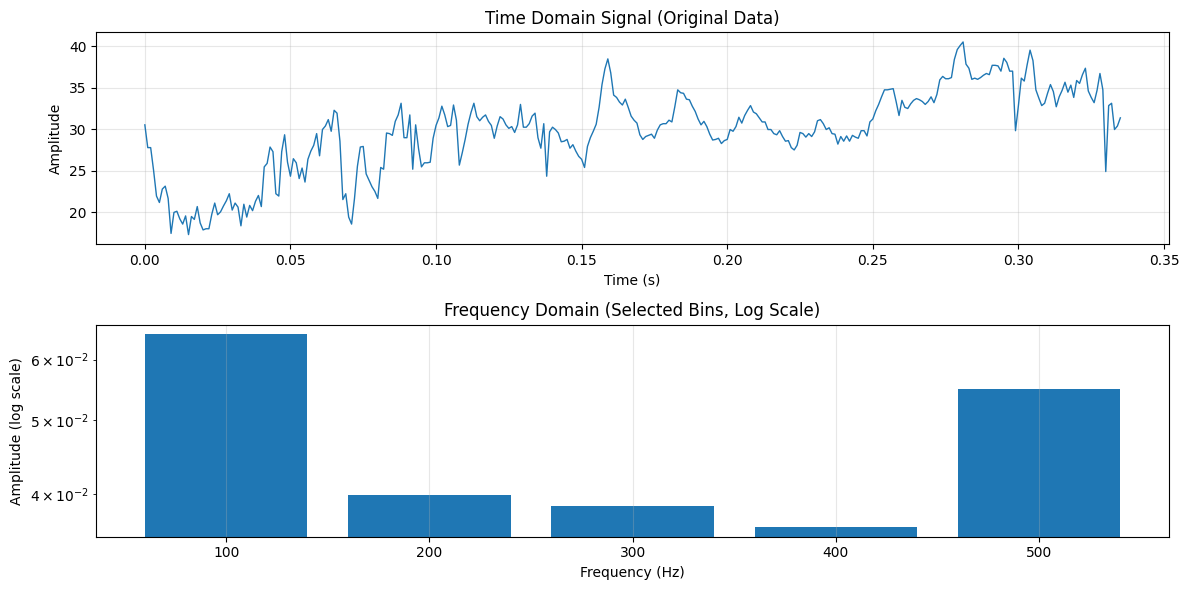

In [15]:
# plot_time_and_fft(
#     root_path=root_path,
#     data="ETTh2",
#     target_col="OT",
#     dt=0.1,
#     iloc_start=0,
#     iloc_end=336,
#     max_freq=None
# )

plot_time_and_fft(
    root_path=root_path,
    data="ETTh1",
    target_col="OT",
    dt=0.001,        # 예: 1kHz 샘플링이면 dt=0.001초
    iloc_start=0,
    iloc_end=336,
    max_freq=1000,   # 최대 1000Hz까지만
    freq_step=100    # 100, 200, 300, ... Hz 막대만 그림
)

Saved to /home/yschoi/CLS_spiking_transformer/Bio-inspired-Spiking-Memory-Transformer-for-time-series-representation-learning/forecasting/fig/freq_domain_analysis_ETTh2.pdf


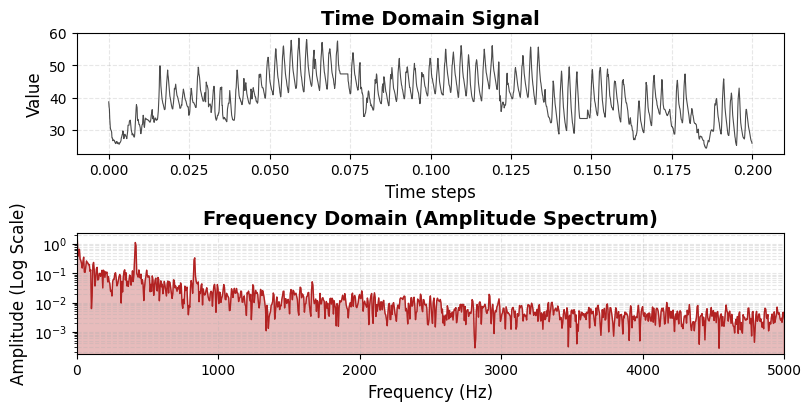

In [4]:
plot_time_and_fft(
    root_path=root_path,
    data="ETTh2",
    target_col="OT",
    dt=0.0001,        # 예: 1kHz 샘플링이면 dt=0.001초
    iloc_start=0,
    iloc_end=2000,
    max_freq=5000,   # 최대 1000Hz까지만
    freq_step=100    # 100, 200, 300, ... Hz 막대만 그림
)

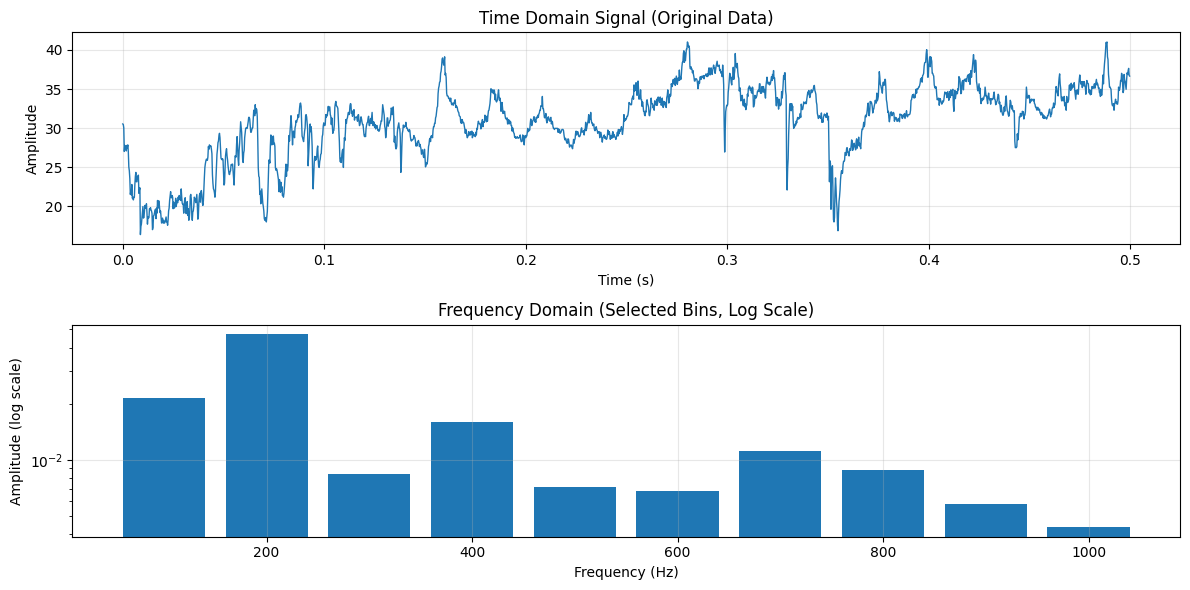

In [24]:
plot_time_and_fft(
    root_path=root_path,
    data="ETTm1",
    target_col="OT",
    dt=0.00025,        # 예: 1kHz 샘플링이면 dt=0.001초
    iloc_start=0,
    iloc_end=2000,
    max_freq=1000,   # 최대 1000Hz까지만
    freq_step=100    # 100, 200, 300, ... Hz 막대만 그림
)